**Polynomial Regression**

In addition to linear terms like 𝑏₁𝑥₁, your regression function 𝑓 can include non-linear terms such as 𝑏₂𝑥₁², 𝑏₃𝑥₁³, or even 𝑏₄𝑥₁𝑥₂, 𝑏₅𝑥₁²𝑥₂, and so on.

The simplest example of polynomial regression has a single independent variable, and the estimated regression function is a polynomial of degree 2: 𝑓(𝑥) = 𝑏₀ + 𝑏₁𝑥 + 𝑏₂𝑥².

Now, remember that you want to calculate 𝑏₀, 𝑏₁, and 𝑏₂

**Underfitting and Overfitting**

**Underfitting** occurs when a model can’t accurately capture the dependencies among data, usually as a consequence of its own simplicity. It often yields a low 𝑅² with known data and bad generalization capabilities when applied with new data.

**Overfitting** happens when a model learns both dependencies among data and random fluctuations. In other words, a model learns the existing data too well. Complex models, which have many features or terms, are often prone to overfitting. When applied to known data, such models usually yield high 𝑅². However, they often don’t generalize well and have significantly lower 𝑅² when used with new data.

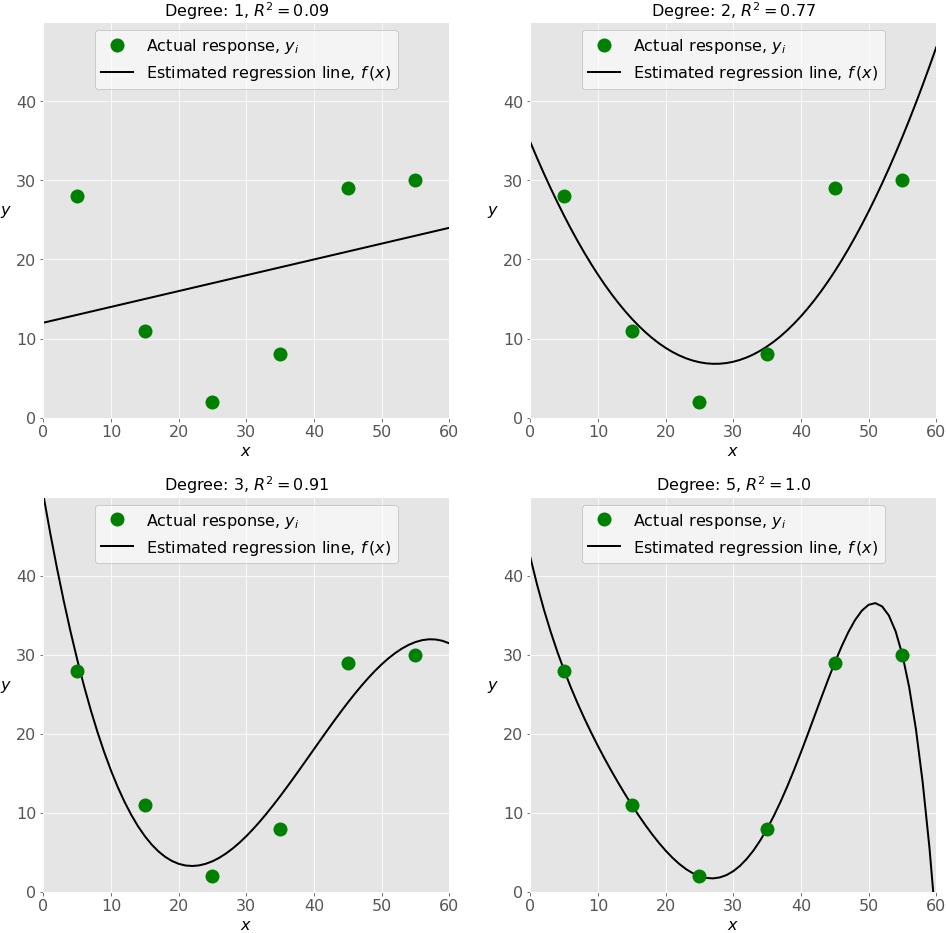

The top left plot shows a linear regression line that has a low 𝑅². It might also be important that a straight line can’t take into account the fact that the actual response increases as 𝑥 moves away from 25 towards zero. This is likely an example of underfitting.

The top right plot illustrates polynomial regression with the degree equal to 2. In this instance, this might be the optimal degree for modeling this data. The model has a value of 𝑅² that is satisfactory in many cases and shows trends nicely.

The bottom left plot presents polynomial regression with the degree equal to 3. The value of 𝑅² is higher than in the preceding cases. This model behaves better with known data than the previous ones. However, it shows some signs of overfitting, especially for the input values close to 60 where the line starts decreasing, although actual data don’t show that.

Finally, on the bottom right plot, you can see the perfect fit: six points and the polynomial line of the degree 5 (or higher) yield 𝑅² = 1. Each actual response equals its corresponding prediction.

**Step 1: Import packages and classes**

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

**Step 2a: Provide data**

In [ ]:
x = np.array([5, 15, 25, 35, 45, 55]).reshape((-1, 1))
y = np.array([15, 11, 2, 8, 25, 32])
x


array([[ 5],
       [15],
       [25],
       [35],
       [45],
       [55]])

Keep in mind that you need the input to be a two-dimensional array. That’s why .reshape() is used.

**Step 2b: Transform input data**

As you’ve seen earlier, you need to include 𝑥² (and perhaps other terms) as additional features when implementing polynomial regression. For that reason, you should transform the input array x to contain the additional column(s) with the values of 𝑥² (and eventually more features).

It’s possible to transform the input array in several ways (like using insert() from numpy), but the class PolynomialFeatures is very convenient for this purpose. Let’s create an instance of this class:

In [ ]:
transformer = PolynomialFeatures(degree=2, include_bias=False)

The variable transformer refers to an instance of PolynomialFeatures which you can use to transform the input x.

You can provide several optional parameters to PolynomialFeatures:

degree is an integer (2 by default) that represents the degree of the polynomial regression function.
interaction_only is a Boolean (False by default) that decides whether to include only interaction features (True) or all features (False).
include_bias is a Boolean (True by default) that decides whether to include the bias (intercept) column of ones (True) or not (False).

This example uses the default values of all parameters, but you’ll sometimes want to experiment with the degree of the function, and it can be beneficial to provide this argument anyway.

Before applying transformer, you need to fit it with .fit():

In [ ]:
transformer.fit(x)

PolynomialFeatures(include_bias=False)

Once transformer is fitted, it’s ready to create a new, modified input. You apply .transform() to do that:


In [ ]:
x_ = transformer.transform(x)

That’s the transformation of the input array with .transform(). It takes the input array as the argument and returns the modified array.

You can also use .fit_transform() to replace the three previous statements with only one:

**x_ = PolynomialFeatures(degree=2, include_bias=False).fit_transform(x)**

That’s fitting and transforming the input array in one statement with .fit_transform(). It also takes the input array and effectively does the same thing as .fit() and .transform() called in that order. It also returns the modified array. This is how the new input array looks:

In [ ]:
print(x_)

[[   5.   25.]
 [  15.  225.]
 [  25.  625.]
 [  35. 1225.]
 [  45. 2025.]
 [  55. 3025.]]


The modified input array contains two columns: one with the original inputs and the other with their squares.

**Step 3: Create a model and fit it**

In [ ]:
model = LinearRegression().fit(x_, y)

You should keep in mind that the first argument of .fit() is the modified input array x_ and not the original x.

**Step 4: Get results**

In [ ]:
r_sq = model.score(x_, y)
print('coefficient of determination:', r_sq)
print('intercept:', model.intercept_)
print('coefficients:', model.coef_)

coefficient of determination: 0.8908516262498563
intercept: 21.37232142857144
coefficients: [-1.32357143  0.02839286]


intercept_ represents 𝑏₀,

while .coef_ references the array that contains 𝑏₁ and 𝑏₂ respectively.

**Another way to get the same results**

In [ ]:
x_ = PolynomialFeatures(degree=2, include_bias=True).fit_transform(x)

If you call PolynomialFeatures with the default parameter **include_bias=True** (or if you just omit it), you’ll obtain the new input array x_ with the additional leftmost column containing only ones. This column corresponds to the intercept. This is how the modified input array looks in this case:

In [ ]:
print(x_)

[[1.000e+00 5.000e+00 2.500e+01]
 [1.000e+00 1.500e+01 2.250e+02]
 [1.000e+00 2.500e+01 6.250e+02]
 [1.000e+00 3.500e+01 1.225e+03]
 [1.000e+00 4.500e+01 2.025e+03]
 [1.000e+00 5.500e+01 3.025e+03]]


The first column of x_ contains ones, the second has the values of x, while the third holds the squares of x.

The intercept is already included with the leftmost column of ones, and you don’t need to include it again when creating the instance of LinearRegression. Thus, you can provide **fit_intercept=False.** This is how the next statement looks:

In [ ]:
model = LinearRegression(fit_intercept=False).fit(x_, y)

In [ ]:
r_sq = model.score(x_, y)
print('coefficient of determination:', r_sq)
print('intercept:', model.intercept_)
print('coefficients:', model.coef_)

coefficient of determination: 0.8908516262498564
intercept: 0.0
coefficients: [21.37232143 -1.32357143  0.02839286]


You see that now .intercept_ is zero, but .coef_ actually contains 𝑏₀ as its first element. Everything else is the same.

**Step 5: Predict response**

In [ ]:
y_pred = model.predict(x_)
print('predicted response:', y_pred, sep='\n')

predicted response:
[15.46428571  7.90714286  6.02857143  9.82857143 19.30714286 34.46428571]


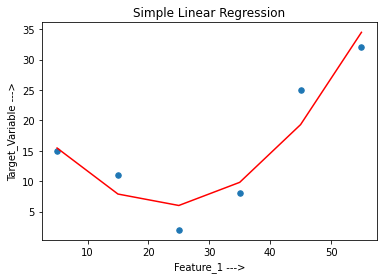

In [ ]:
import matplotlib.pyplot as plt
# Plot the output.
plt.scatter(x,y,s=30,marker='o')
plt.plot(x,y_pred,c='red')
plt.plot()
plt.xlabel("Feature_1 --->")
plt.ylabel("Target_Variable --->")
plt.title('Simple Linear Regression')
plt.show()

**several input variables**

You’ll have an input array with more than one column, but everything else is the same. Here is an example:

In [ ]:
# Step 1: Import packages
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Step 2a: Provide data
x = [[0, 1], [5, 1], [15, 2], [25, 5], [35, 11], [45, 15], [55, 34], [60, 35]]
y = [4, 5, 20, 14, 32, 22, 38, 43]
x, y = np.array(x), np.array(y)

# Step 2b: Transform input data
x_ = PolynomialFeatures(degree=2, include_bias=False).fit_transform(x)

# Step 3: Create a model and fit it
model = LinearRegression().fit(x_, y)

# Step 4: Get results
r_sq = model.score(x_, y)
intercept, coefficients = model.intercept_, model.coef_

# Step 5: Predict
y_pred = model.predict(x_)

In [ ]:
print('coefficient of determination:', r_sq)
print('intercept:', intercept)
print('coefficients:', coefficients, sep='\n')
print('predicted response:', y_pred, sep='\n')

coefficient of determination: 0.9453701449127822
intercept: 0.8430556452395876
coefficients:
[ 2.44828275  0.16160353 -0.15259677  0.47928683 -0.4641851 ]
predicted response:
[ 0.54047408 11.36340283 16.07809622 15.79139    29.73858619 23.50834636
 39.05631386 41.92339046]
